In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics

plt.style.use("ggplot")

%matplotlib inline

In [233]:
plt.rcParams["figure.figsize"] = (12, 6)

Download stock price data from NSE [website](https://www.nseindia.com/products/content/equities/equities/eq_security.htm). Here I download stock price data for TCS stock.


In [234]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/master/tcs-stock.csv")
df.head()

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,TCS,EQ,31-May-2018,3514.10,1734.0,1759.05,1726.10,1748.85,1741.05,1742.44,5049371,8.798250e+09,207998,3447026,68.27
1,TCS,EQ,01-Jun-2018,1741.05,1754.0,1757.50,1716.30,1732.00,1732.45,1742.29,1603856,2.794386e+09,74272,924751,57.66
2,TCS,EQ,04-Jun-2018,1732.45,1745.0,1749.00,1712.60,1742.00,1744.25,1730.25,1681483,2.909394e+09,96686,928452,55.22
3,TCS,EQ,05-Jun-2018,1744.25,1744.0,1751.90,1711.15,1723.00,1721.60,1728.88,2449568,4.235001e+09,133067,1492228,60.92
4,TCS,EQ,06-Jun-2018,1721.60,1723.0,1734.90,1715.20,1725.00,1725.75,1725.85,2236512,3.859875e+09,73770,1573892,70.37


Check whether you have duplicate data on by date. It looks like 11/2/2019, 18/2/2019, 25/2/2019 etc. have duplicate data. Not sure why there are duplicates by date. It could be ammendment to the data.

In [235]:
df[df["Date"].duplicated(keep = False)]

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
173,TCS,BL,11-Feb-2019,2604.20,2061.40,2061.40,2061.40,2061.40,2061.40,2061.40,376308,7.757213e+08,1,0,0.00
174,TCS,EQ,11-Feb-2019,2061.40,2060.00,2096.00,2048.90,2065.60,2065.90,2077.11,1778730,3.694622e+09,83603,901516,50.68
179,TCS,BL,18-Feb-2019,2061.40,2029.70,2029.70,2029.70,2029.70,2029.70,2029.70,2474600,5.022696e+09,1,0,0.00
180,TCS,EQ,18-Feb-2019,2029.70,2037.60,2041.95,1962.65,1969.60,1970.30,1988.87,2942184,5.851634e+09,100585,1668905,56.72
185,TCS,BL,25-Feb-2019,2029.70,1925.65,1925.65,1925.65,1925.65,1925.65,1925.65,1057509,2.036392e+09,2,0,0.00
186,TCS,EQ,25-Feb-2019,1925.65,1932.50,1990.00,1930.50,1987.00,1985.15,1961.61,2934880,5.757095e+09,140541,1341508,45.71
203,TCS,BL,22-Mar-2019,1925.65,2015.05,2015.05,2015.05,2015.05,2015.05,2015.05,264913,5.338129e+08,1,264913,100.00
204,TCS,EQ,22-Mar-2019,2015.05,2015.00,2016.00,1983.30,2010.00,2005.65,1998.96,3148149,6.293032e+09,155770,1787595,56.78


Drop the duplicate from the dataset.

In [236]:
df = df[~df["Date"].duplicated()]

Convert the dataset into time series data by undating the index to time series index.

In [237]:
df.index = pd.to_datetime(df["Date"], format="%d-%b-%Y")
df.head()

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
Date,,,,,,,,,,,,,,,
2018-05-31,TCS,EQ,31-May-2018,3514.10,1734.0,1759.05,1726.10,1748.85,1741.05,1742.44,5049371,8.798250e+09,207998,3447026,68.27
2018-06-01,TCS,EQ,01-Jun-2018,1741.05,1754.0,1757.50,1716.30,1732.00,1732.45,1742.29,1603856,2.794386e+09,74272,924751,57.66
2018-06-04,TCS,EQ,04-Jun-2018,1732.45,1745.0,1749.00,1712.60,1742.00,1744.25,1730.25,1681483,2.909394e+09,96686,928452,55.22
2018-06-05,TCS,EQ,05-Jun-2018,1744.25,1744.0,1751.90,1711.15,1723.00,1721.60,1728.88,2449568,4.235001e+09,133067,1492228,60.92
2018-06-06,TCS,EQ,06-Jun-2018,1721.60,1723.0,1734.90,1715.20,1725.00,1725.75,1725.85,2236512,3.859875e+09,73770,1573892,70.37


In [238]:
df.index

DatetimeIndex(['2018-05-31', '2018-06-01', '2018-06-04', '2018-06-05',
               '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-11',
               '2018-06-12', '2018-06-13',
               ...
               '2019-05-17', '2019-05-20', '2019-05-21', '2019-05-22',
               '2019-05-23', '2019-05-24', '2019-05-27', '2019-05-28',
               '2019-05-29', '2019-05-30'],
              dtype='datetime64[ns]', name='Date', length=246, freq=None)

<Axes: xlabel='Date'>

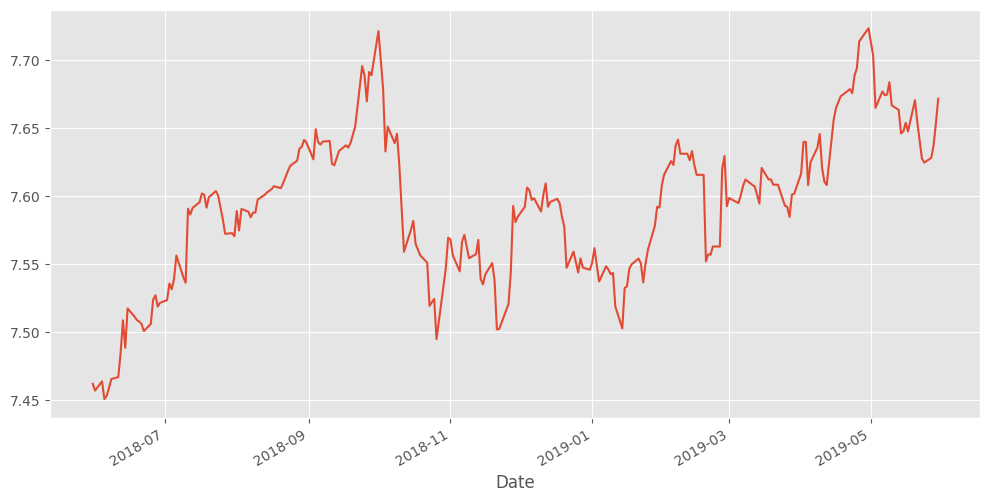

In [239]:
y = np.log(df["Close Price"])
y.plot()

In [240]:
y.index

DatetimeIndex(['2018-05-31', '2018-06-01', '2018-06-04', '2018-06-05',
               '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-11',
               '2018-06-12', '2018-06-13',
               ...
               '2019-05-17', '2019-05-20', '2019-05-21', '2019-05-22',
               '2019-05-23', '2019-05-24', '2019-05-27', '2019-05-28',
               '2019-05-29', '2019-05-30'],
              dtype='datetime64[ns]', name='Date', length=246, freq=None)

Let's see if there are gaps in the data in terms of date range. Trading does not happen on weekends or national holidays. So there is no data on those days.

In [241]:
list(y.index[:10])

[Timestamp('2018-05-31 00:00:00'),
 Timestamp('2018-06-01 00:00:00'),
 Timestamp('2018-06-04 00:00:00'),
 Timestamp('2018-06-05 00:00:00'),
 Timestamp('2018-06-06 00:00:00'),
 Timestamp('2018-06-07 00:00:00'),
 Timestamp('2018-06-08 00:00:00'),
 Timestamp('2018-06-11 00:00:00'),
 Timestamp('2018-06-12 00:00:00'),
 Timestamp('2018-06-13 00:00:00')]

In [242]:
y.asfreq("D")[:15]

,Close Price
Date,
2018-05-31,7.462244
2018-06-01,7.457292
2018-06-02,NaN
2018-06-03,NaN
2018-06-04,7.464080
2018-06-05,7.451009
2018-06-06,7.453417
2018-06-07,7.459080
2018-06-08,7.465713


Let's impute the missing data by forward fill using asfreq method.

In [243]:
y.asfreq("D", method="ffill")[:15]

,Close Price
Date,
2018-05-31,7.462244
2018-06-01,7.457292
2018-06-02,7.457292
2018-06-03,7.457292
2018-06-04,7.464080
2018-06-05,7.451009
2018-06-06,7.453417
2018-06-07,7.459080
2018-06-08,7.465713


For legitimate gaps, we can also set frequency to business days ("B")

In [244]:
y = y.asfreq("B")
y.index

DatetimeIndex(['2018-05-31', '2018-06-01', '2018-06-04', '2018-06-05',
               '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-11',
               '2018-06-12', '2018-06-13',
               ...
               '2019-05-17', '2019-05-20', '2019-05-21', '2019-05-22',
               '2019-05-23', '2019-05-24', '2019-05-27', '2019-05-28',
               '2019-05-29', '2019-05-30'],
              dtype='datetime64[ns]', name='Date', length=261, freq='B')

Calculate quarterly high, low etc.

In [245]:
pd.DataFrame(dict(low=y.resample("Q").min(),
                  high=y.resample("Q").max(),
                  first = y.resample("Q").first(),
                  last = y.resample("Q").last(),
                  median = y.resample("Q").median(),
                  mean = y.resample("Q").mean()
                 ))

/tmp/ipykernel_14014/1471766711.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  pd.DataFrame(dict(low=y.resample("Q").min(),
/tmp/ipykernel_14014/1471766711.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  high=y.resample("Q").max(),
/tmp/ipykernel_14014/1471766711.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  first = y.resample("Q").first(),
/tmp/ipykernel_14014/1471766711.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  last = y.resample("Q").last(),
/tmp/ipykernel_14014/1471766711.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  median = y.resample("Q").median(),
/tmp/ipykernel_14014/1471766711.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' inste

,low,high,first,last,median,mean
Date,,,,,,
2018-06-30,7.451009,7.527256,7.462244,7.521724,7.503576,7.491539
2018-09-30,7.523670,7.695508,7.523670,7.688776,7.602676,7.607829
2018-12-31,7.495042,7.721149,7.721149,7.545945,7.567837,7.572861
2019-03-31,7.502876,7.641516,7.551082,7.601727,7.593789,7.585512
2019-06-30,7.608126,7.723275,7.616604,7.671501,7.654088,7.655684


Calculate rolling mean, exponentially weighted mean

In [246]:
period = 3
y_rolling = pd.DataFrame(dict(actual = y,
                              rolling_mean = y.rolling(period).mean(),
                              ewm = y.ewm(span = period).mean()
                             ))
y_rolling.head(10)

,actual,rolling_mean,ewm
Date,,,
2018-05-31,7.462244,NaN,7.462244
2018-06-01,7.457292,NaN,7.458942
2018-06-04,7.464080,7.461205,7.461878
2018-06-05,7.451009,7.457460,7.456081
2018-06-06,7.453417,7.456169,7.454706
2018-06-07,7.459080,7.454502,7.456928
2018-06-08,7.465713,7.459403,7.461355
2018-06-11,7.467200,7.463997,7.464289
2018-06-12,7.484930,7.472614,7.474630


In [247]:
rolling_dropped = y_rolling.dropna()
print("rmse over rolling mean: ", metrics.mean_squared_error(rolling_dropped.actual, rolling_dropped.rolling_mean) ** 0.5)
print("rmse over ewma: ", metrics.mean_squared_error(rolling_dropped.actual, rolling_dropped["ewm"]) ** 0.5)

rmse over rolling mean:  0.01122680111697439
rmse over ewma:  0.008422829060485497


By visual inspection, we see the time series is not stationary. Let we will see a more formal way of testing using Dickey Fullter Test.

<Axes: xlabel='Date'>

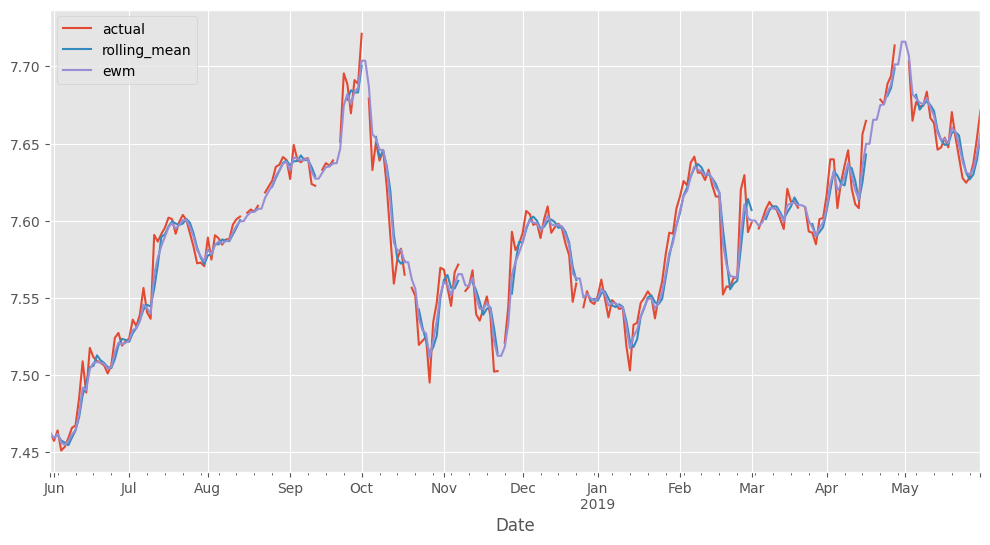

In [248]:
y_rolling.plot()

Formal of way of test for stationarity. Since the p-value of Augmented Dickey Fullter test is > 0.05, we can say that there is not sufficient proof that the time series is stationary. Loosely speaking, it is non-stationary. We need further transformation to make data stationary. Populary method for making data stationary will be to take "difference". Taking difference by lag one, we see the p-val for Dickey Fuller test is < 0.05. So we conclude, diff 1 has made the data stationary.

In [249]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(y.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -2.645513
p-value: 0.083951


In [250]:
diff = pd.DataFrame({"actual": y, "diff1": y.diff(3)}).head(10)
diff["diff2"] = diff.diff1.diff(1)
diff

,actual,diff1,diff2
Date,,,
2018-05-31,7.462244,NaN,NaN
2018-06-01,7.457292,NaN,NaN
2018-06-04,7.464080,NaN,NaN
2018-06-05,7.451009,-0.011234,NaN
2018-06-06,7.453417,-0.003875,0.007359
2018-06-07,7.459080,-0.005000,-0.001125
2018-06-08,7.465713,0.014703,0.019703
2018-06-11,7.467200,0.013783,-0.000921
2018-06-12,7.484930,0.025851,0.012068


In [251]:
result = adfuller(y.diff(periods=1).dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -16.354529
p-value: 0.000000


<Axes: xlabel='Date'>

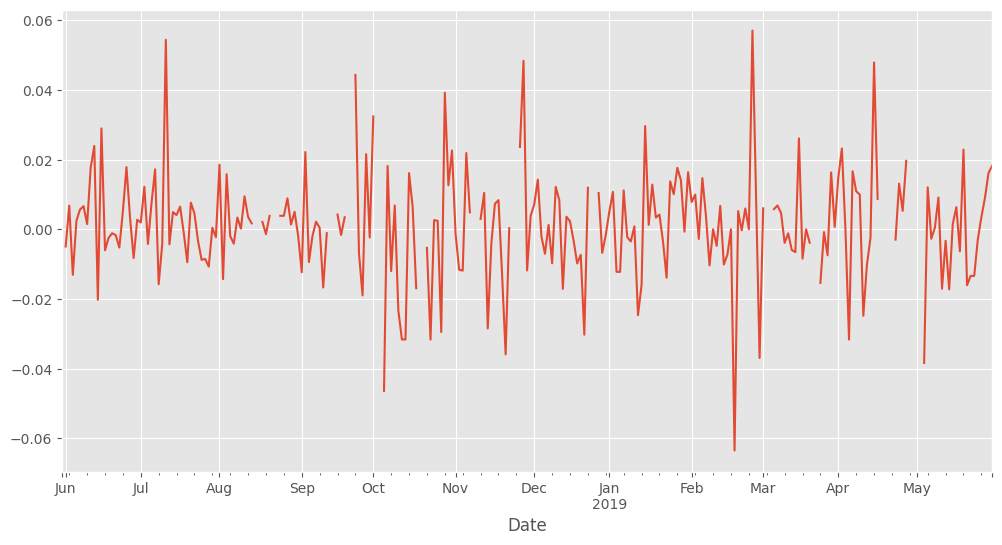

In [252]:
y.diff(periods=1).plot()

Use pandas's auto correlation plot. Here is a nice explanation of the [autocorrelation plot](https://stats.stackexchange.com/questions/357300/what-does-pandas-autocorrelation-graph-show)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

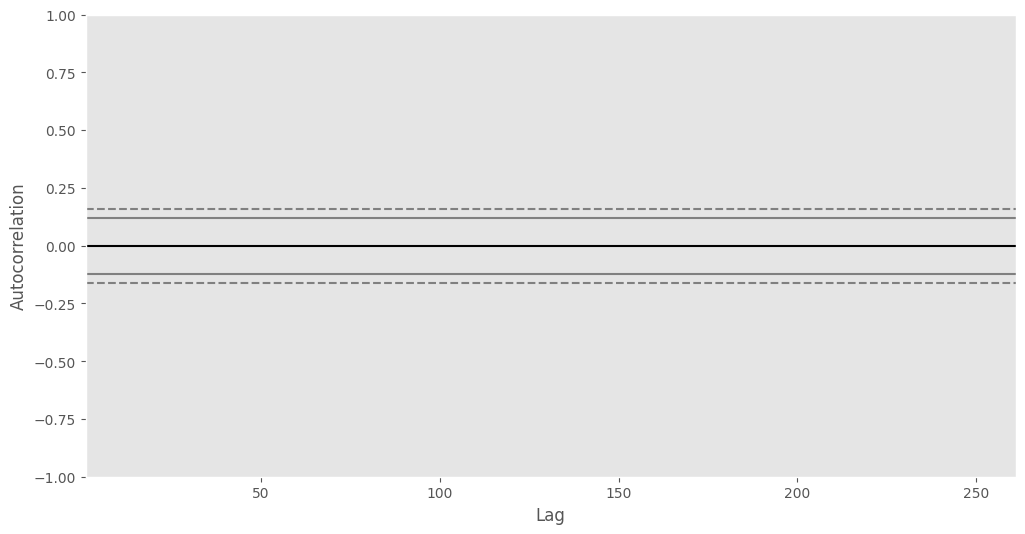

In [253]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(y)

In [254]:
y = y.dropna()

                0
count  246.000000
mean     0.031238
std      0.475974
min     -0.063745
25%     -0.006632
50%      0.001217
75%      0.008914
max      7.462244


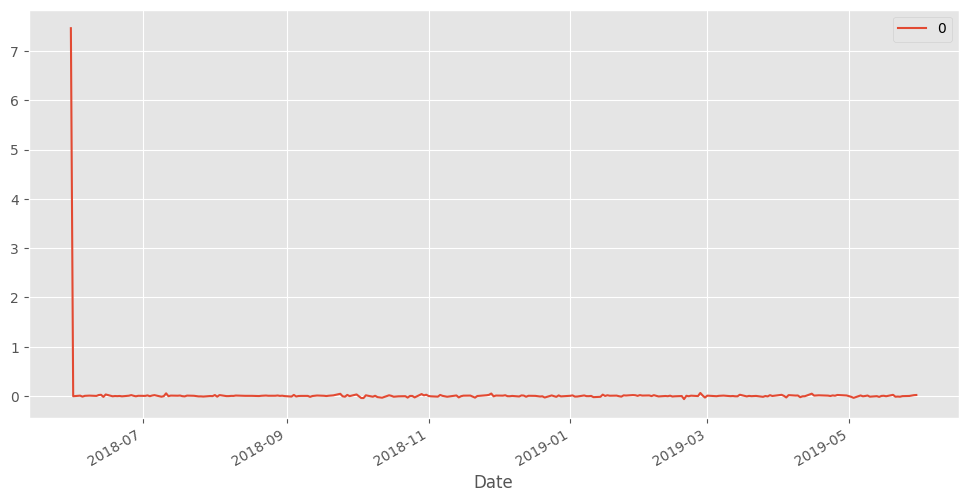

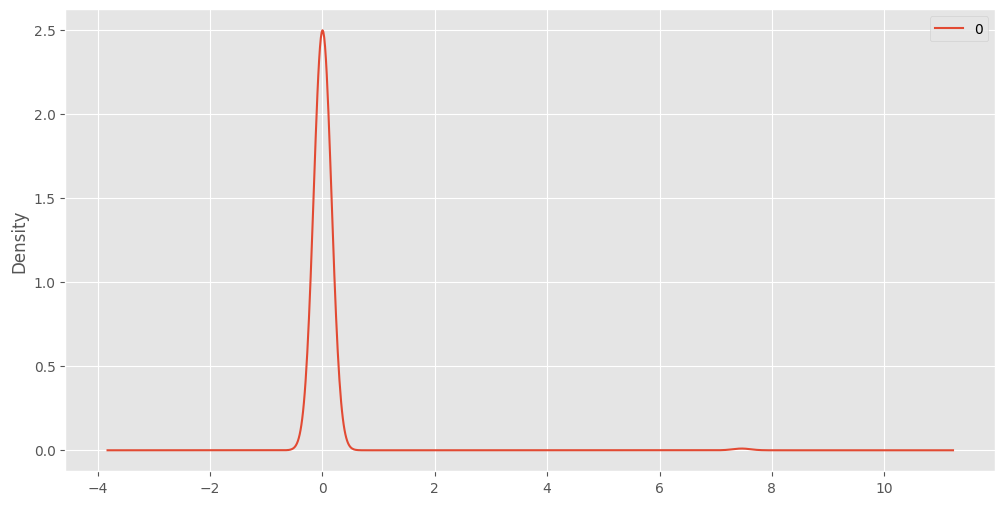

In [255]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Suppress the specific ValueWarning from statsmodels
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.")

# Ensure y has no frequency information, as it's not a truly regular series after dropna()
y.index.freq = None

# fit model
model = ARIMA(y, order=(5,1,0)) # p, d, q
model_fit = model.fit()
#print(model_fit.summary())

# plot residual erros
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
residuals.plot(kind='kde')
print(residuals.describe())

In [256]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Close Price   No. Observations:                  246
Model:                 ARIMA(5, 1, 0)   Log Likelihood                 670.993
Date:                Thu, 26 Mar 2026   AIC                          -1329.985
Time:                        16:36:06   BIC                          -1308.978
Sample:                             0   HQIC                         -1321.526
                                - 246                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0090      0.063     -0.143      0.887      -0.133       0.115
ar.L2         -0.0805      0.060     -1.341      0.180      -0.198       0.037
ar.L3         -0.0121      0.070     -0.172      0.863      -0.150       0.126
ar.L4         -0.0302      0.071     -0.423      0.672      -0.170       0.110
ar.L5          0.0577      0.048      1.201      0.230      -0.036       0.152
sigma2         0.0002   1.51e-05     16.146      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                72.62
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.78   Skew:                             0.02
Prob(H) (two-sided):                  0.01   Kurtosis:                         5.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

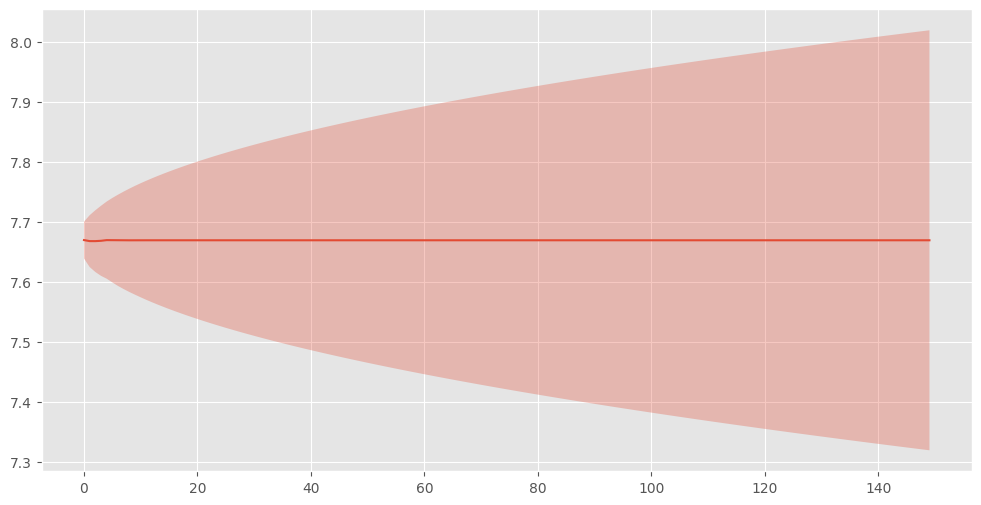

In [257]:
model = ARIMA(y.values, order=(5,1,0))
model_fit = model.fit()
forecast_results = model_fit.get_forecast(steps=150)
predictions = forecast_results.predicted_mean
conf_interval = forecast_results.conf_int()
plt.plot(predictions)
plt.fill_between(range(len(predictions)), conf_interval[:,0], conf_interval[:,1], alpha = 0.3)

In [258]:
predictions[:10]

array([7.66964978, 7.66793331, 7.66790976, 7.66845389, 7.6695788 ,
       7.66947007, 7.66927556, 7.6692547 , 7.66926933, 7.66934142])

In [259]:
forecast_results.se_mean[:10]

array([0.01563915, 0.02201729, 0.02622079, 0.02975885, 0.03276348,
       0.03588752, 0.03878058, 0.04142319, 0.04390278, 0.04623742])

In [260]:
conf_interval[:10]

array([[7.63899762, 7.70030195],
       [7.62478021, 7.71108642],
       [7.61651796, 7.71930156],
       [7.61012761, 7.72678016],
       [7.60536356, 7.73379405],
       [7.59913184, 7.73980831],
       [7.59326702, 7.7452841 ],
       [7.58806673, 7.75044267],
       [7.58322146, 7.75531719],
       [7.57871774, 7.7599651 ]])

In [261]:
model.endog

array([[7.46224366],
       [7.45729187],
       [7.46407994],
       [7.45100937],
       [7.45341702],
       [7.45907965],
       [7.46571255],
       [7.46719962],
       [7.48493028],
       [7.50884199],
       [7.48860125],
       [7.51754802],
       [7.51152465],
       [7.50906126],
       [7.50793703],
       [7.50623457],
       [7.50097162],
       [7.50617961],
       [7.52402142],
       [7.52725592],
       [7.51898717],
       [7.52172396],
       [7.52367038],
       [7.53585714],
       [7.53163276],
       [7.53918662],
       [7.55640183],
       [7.54062153],
       [7.53641727],
       [7.59080162],
       [7.58647387],
       [7.59140752],
       [7.59548783],
       [7.60197688],
       [7.60102745],
       [7.59155894],
       [7.59920101],
       [7.60372348],
       [7.60040233],
       [7.59160941],
       [7.58309484],
       [7.57237438],
       [7.57281158],
       [7.57054634],
       [7.58908288],
       [7.5747638 ],
       [7.59057431],
       [7.588

In [262]:
(predictions + 1.96 * error)[:10]

array([7.67025508, 7.66853861, 7.66851506, 7.66905919, 7.6701841 ,
       7.67007537, 7.66988086, 7.66985999, 7.66987462, 7.66994672])

In [263]:
(predictions - 1.96 * error)[:10]

array([7.66904449, 7.66732802, 7.66730446, 7.66784859, 7.66897351,
       7.66886478, 7.66867026, 7.6686494 , 7.66866403, 7.66873612])

predicted=7.641516, actual=7.631141
predicted=7.633396, actual=7.631141
predicted=7.631669, actual=7.626375
predicted=7.628235, actual=7.633079
predicted=7.633930, actual=7.622957
predicted=7.620844, actual=7.615643
predicted=7.616879, actual=7.615643
predicted=7.614916, actual=7.552132
predicted=7.554105, actual=7.557342
predicted=7.559579, actual=7.557055
predicted=7.551369, actual=7.563019
predicted=7.563684, actual=7.563019
predicted=7.552197, actual=7.620068
predicted=7.619316, actual=7.629539
predicted=7.626866, actual=7.592593
predicted=7.595406, actual=7.598600
predicted=7.601634, actual=7.594935
predicted=7.596674, actual=7.600702
predicted=7.602420, actual=7.607530
predicted=7.603815, actual=7.612189
predicted=7.612283, actual=7.608275
predicted=7.607911, actual=7.607108
predicted=7.607926, actual=7.601152
predicted=7.601579, actual=7.594583
predicted=7.595532, actual=7.620681
predicted=7.620146, actual=7.612238
predicted=7.610059, actual=7.612238
predicted=7.613759, actual=7

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


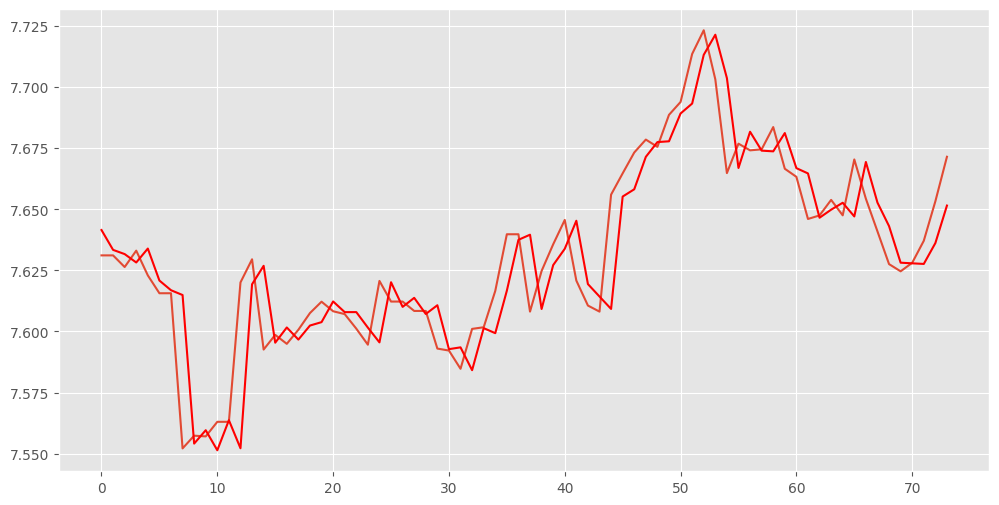

In [264]:
from sklearn.metrics import mean_squared_error

x = y.values
train_size = int(len(x) * 0.7)
train, test = x[0:train_size], x[train_size:]
history = [x for x in train]
predictions = []
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('predicted=%f, actual=%f' % (yhat, obs))
error = mean_squared_error(test, predictions)
print('Test RMSE: %.3f' % np.sqrt(error))

plt.plot(test)
plt.plot(predictions, color='red')

In [265]:
result = pd.DataFrame(y)[train_size:]
result.columns = ["actual"]
result["prediction"] = predictions
result

,actual,prediction
Date,,
2019-02-08,7.631141,7.641516
2019-02-11,7.631141,7.633396
2019-02-12,7.626375,7.631669
2019-02-13,7.633079,7.628235
2019-02-14,7.622957,7.633930
...,...,...
2019-05-24,7.624619,7.628148
2019-05-27,7.628104,7.627890
2019-05-28,7.637114,7.627638


In [266]:
from numpy import array
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [267]:
y_b = np.log(df["Close Price"])
y_b = y_b.asfreq("B").dropna()/10.0
print("%s" % y_b[:10])

Date
2018-05-31    0.746224
2018-06-01    0.745729
2018-06-04    0.746408
2018-06-05    0.745101
2018-06-06    0.745342
2018-06-07    0.745908
2018-06-08    0.746571
2018-06-11    0.746720
2018-06-12    0.748493
2018-06-13    0.750884
Name: Close Price, dtype: float64


In [268]:
n_input = 5
train_size = int(0.7 * len(y_b))
y_b_train = y_b[:train_size]
y_b_test = y_b[train_size:]
generator_train = TimeseriesGenerator(y_b_train, y_b_train, length=n_input, batch_size=1, )
generator_test = TimeseriesGenerator(y_b_test, y_b_test, length=n_input, batch_size=1)
print('Samples: %d' % len(generator_train))
for i in range(3):
    x, y = generator_train[i]
    print('%s => %s' % (x, y))

Samples: 167
[[0.74622437 0.74572919 0.74640799 0.74510094 0.7453417 ]] => [0.74590796]
[[0.74572919 0.74640799 0.74510094 0.7453417  0.74590796]] => [0.74657125]
[[0.74640799 0.74510094 0.7453417  0.74590796 0.74657125]] => [0.74671996]


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/sequence.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  targets = np.array([self.targets[row] for row in rows])


In [269]:
n_input = 5
tf.random.set_seed(1)
np.random.seed(1)


model = keras.Sequential([
    keras.layers.InputLayer(shape = (n_input,)),
    keras.layers.Dense(1, activation = None, kernel_initializer = keras.initializers.he_uniform(seed = 1))
])
model.compile(loss = "mse", optimizer = keras.optimizers.SGD(learning_rate = 0.1))
model.summary()

model.fit(generator_train, steps_per_epoch=1, epochs=500, verbose=0)
y_b_test_pred = model.predict(generator_test)
layer = model.layers[0]
print(layer.get_weights())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[array([[ 0.94966763],
       [ 0.03310137],
       [ 0.34049925],
       [-0.11420814],
       [-0.41925737]], dtype=float32), array([0.1589689], dtype=float32)]


In [270]:
y_b_test_pred.shape, y_b_test.shape

((69, 1), (74,))

In [271]:
metrics.mean_squared_error(y_b_test[n_input:] * 10.0, y_b_test_pred * 10.0) ** 0.5

0.043651368585516416

In [272]:
y_b = y_b.values
y_b = y_b.reshape((len(y_b), 1))

train_size = int(0.7 * len(y_b))
y_b_train = y_b[:train_size]
y_b_test = y_b[train_size:]

n_input = 5

generator_train = TimeseriesGenerator(y_b_train, y_b_train, length=n_input, batch_size=1, )
generator_test = TimeseriesGenerator(y_b_test, y_b_test, length=n_input, batch_size=1)
print('Samples: %d' % len(generator_train))
for i in range(3):
    x, y = generator_train[i]
    print('%s => %s' % (x, y))


Samples: 167
[[[0.74622437]
  [0.74572919]
  [0.74640799]
  [0.74510094]
  [0.7453417 ]]] => [[0.74590796]]
[[[0.74572919]
  [0.74640799]
  [0.74510094]
  [0.7453417 ]
  [0.74590796]]] => [[0.74657125]]
[[[0.74640799]
  [0.74510094]
  [0.7453417 ]
  [0.74590796]
  [0.74657125]]] => [[0.74671996]]


In [273]:
model = keras.Sequential([
    keras.layers.InputLayer(input_shape = (n_input,1)),
    keras.layers.LSTM(units = 100),
    keras.layers.Dense(units = 1, activation = None)
])
model.compile(loss = "mse", optimizer = "adam")
model.summary()

model.fit(generator_train, steps_per_epoch=1, epochs=500, verbose=1)
y_b_test_pred = model.predict(generator_test)
layer = model.layers[0]
#print(layer.get_weights())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6137
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5627
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5081
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4415
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3941
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3296
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2909
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2464
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2018
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1606
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1259
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0936
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0661
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0403
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0229
Epoch 16/500
1/1 ━━━━

In [274]:
y_b_test_pred.shape, y_b_test.shape

((69, 1), (74, 1))

In [275]:
y_b_test_pred.shape, y_b_test.shape

((69, 1), (74, 1))

In [276]:
metrics.mean_squared_error(y_b_test[n_input:] * 10.0, y_b_test_pred * 10.0) ** 0.5

0.025174334597423655